In [1]:
from scMM.file._anndata import MetaboData
import pandas as pd
import numpy as np

df = pd.read_csv("/home/zby/scMM/data/ethology_new/Compound_measurements.csv")
sample_mask = df.columns.to_series().str.match(r"^WORM-\d{8}$")
IS_MASK = df["IS"].values == "x"
IS_inten = df.loc[IS_MASK, :]
df = df.loc[IS_MASK == False, :]
high_mean = df["Highest Mean"].values
low_mean = df["Lowest Mean"].values
FC = df["Max Fold Change"].values
data = MetaboData(
    X = df.loc[:, sample_mask].values.T,
    obs = pd.DataFrame({
        "name": df.columns[sample_mask].values
    }),
    var = pd.DataFrame({
        "mz": df["m/z"].values,
        "rt": df["Retention time (min)"].values,
        "isotope": df["Isotope Distribution"].values,
        "snr": [FC[i] if high_mean[i] == "Condition 1" else 1/FC[i] for i in range(len(FC))],
        "identification": df["Accepted Description"].values
    }),
    is_inten = IS_inten.loc[:, sample_mask].T
)
is_mz_obs = IS_inten["m/z"].values

/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [2]:
from matplotlib import font_manager
import matplotlib.pyplot as plt

fname = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"

font_manager.fontManager.addfont(fname)

prop = font_manager.FontProperties(fname=fname)
family_name = prop.get_name()

plt.rcParams["font.family"] = family_name

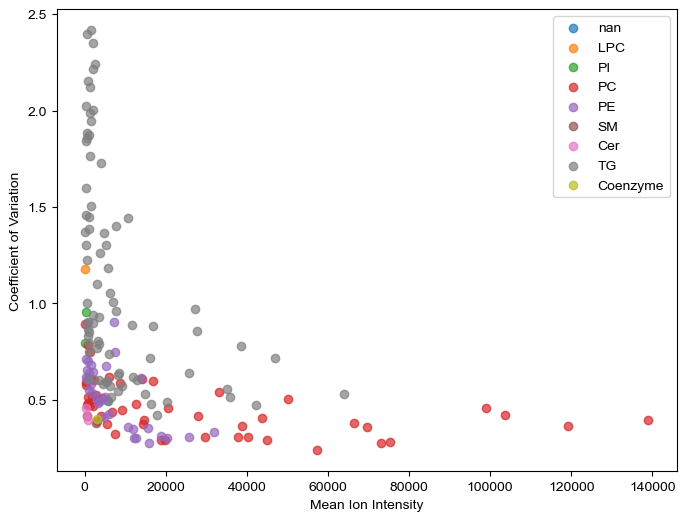

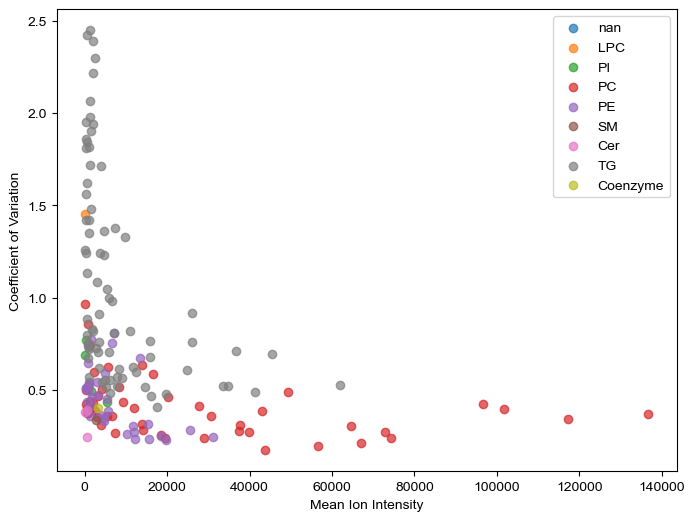

In [3]:
data.var["label"] = data.var["identification"].str.extract(r"^([A-Za-z]+)")[0]
data.plot_features(color_key = "label", save_path="/home/zby/scMM/data/ethology_new/feature_plot_WT_30_uncalib.svg")
data.gmis_calibration(n_pc = 3, shrinkage = 0.7, is_cv_threshold=0.3)
data.plot_features(color_key = "label", save_path="/home/zby/scMM/data/ethology_new/feature_plot_WT_30_calib.svg")

In [4]:
eth_df = pd.read_csv("/home/zby/scMM/data/ethology_new/edited/features_summary_tierpsy_trajectory_manual_20260129_132814.csv", index_col=0)

features = eth_df.columns
remove_patterns = [
    "blob",
    "hu",
    "compactness",
    "solidity",
    "quirkiness"
]

remove_body_parts = [
    "head_tip",
    "neck",
    "hips",
    "tail_tip"
]

remove_stats = [
    "_10th",
    "mean",
    "std"
]

def filter_feature(name):

    for p in remove_patterns:
        if p in name:
            return False

    for p in remove_body_parts:
        if p in name:
            return False

    for p in remove_stats:
        if p in name:
            return False

    return True


filtered_features = [f for f in features if filter_feature(f)]

df_filtered = eth_df[filtered_features]
nan_mask = df_filtered.isna().all(axis=0)
df_filtered = df_filtered.loc[:, ~nan_mask]

print("original features:", len(features))
print("filtered features:", len(filtered_features))

original features: 4539
filtered features: 1438


In [5]:
from collections import Counter
import re

features = df_filtered.columns

tokens = []

feature_kws = [
    "speed",
    "velocity",
    "angular_velocity",
    "curvature",
    "path",
    "radial_velocity",
    "forward",
    "backward",
    "paused",
    "amplitude",
    "wavelength",
    "curvature",
    "radial",
    "angular",
    "midbody",
    "head",
    "tail"
]

for f in features:

    words = re.split("_", f)

    for w in words:

        if w in feature_kws:

            tokens.append(w)

counts = Counter(tokens)

print(counts.most_common(20))

[('curvature', 420), ('backward', 297), ('forward', 297), ('paused', 297), ('midbody', 289), ('path', 280), ('head', 238), ('tail', 238), ('angular', 192), ('velocity', 192), ('speed', 162)]


In [6]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_filtered = pd.DataFrame(imputer.fit_transform(df_filtered), columns=df_filtered.columns)

In [7]:
from scMM.plot import CorrAnalEngine
from anndata import AnnData

corr_engine = CorrAnalEngine(lipid = data, 
                             save_path="/home/zby/scMM/data/ethology_new/",
                             ethology = AnnData(X = df_filtered.values, 
                                               obs = pd.DataFrame(index=df_filtered.index), 
                                               var = pd.DataFrame({"name": df_filtered.columns})))

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [8]:
corr_engine.corr_heatmap(
    omic1 = "lipid",
    omic2 = "ethology",
    feature_name_key1 = "identification",
    feature_name_key2 = "name",
    method = "spearman")

In [9]:
corr_engine.kw_enrichment_wordcloud("ethology_cluster", 
                                 word_include=feature_kws, 
                                 font_path="/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf",
                                 spines_visible=True)

In [10]:
corr_engine.uns["lipid_cluster"].to_csv("/home/zby/scMM/data/ethology_new/lipid_cluster.csv")

In [11]:
from scMM.plot import batch_lion_wordclouds
batch_lion_wordclouds(
    csv_glob="/home/zby/scMM/data/ethology_new/lipid_clusters_0303/LION-enrichment-clust*.csv",
    out_dir="/home/zby/scMM/data/ethology_new/lipid_clusters_0303/",
    top_k=3,
    q_thresh=0.05,
    font_path="/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf",
    spines_visible=True
)

,cluster,input_file,n_terms_after_filter,svg_written,svg_path
0,clust1,LION-enrichment-clust1.csv,3,True,/home/zby/scMM/data/ethology_new/lipid_cluster...
1,clust2,LION-enrichment-clust2.csv,3,True,/home/zby/scMM/data/ethology_new/lipid_cluster...
2,clust3,LION-enrichment-clust3.csv,1,True,/home/zby/scMM/data/ethology_new/lipid_cluster...
3,clust4,LION-enrichment-clust4.csv,2,True,/home/zby/scMM/data/ethology_new/lipid_cluster...
4,clust5,LION-enrichment-clust5.csv,3,True,/home/zby/scMM/data/ethology_new/lipid_cluster...
5,clust6,LION-enrichment-clust6.csv,1,True,/home/zby/scMM/data/ethology_new/lipid_cluster...


In [12]:
corr_engine.plot_corr_dist(
    omics1 = "lipid",
    omics2 = "ethology",
    method = "pearson",
    show_random_corr = True,
    random_seed = 42,
    figsize = (6, 4),
    bins = 50
)

(array([0.23607038, 0.04178886, 0.13636364, ..., 0.00109971, 0.17998534,
        0.07221408], shape=(250796,)),
 array([0.00383826, 0.1226597 , 0.04407568, ..., 0.19359232, 0.02385873,
        0.03883132], shape=(250796,)))

In [18]:
corr_engine.plot_gini_dist(
    omics1 = "lipid",
    omics2 = "ethology",
    metric = "abs_r",
    method = "pearson"
)

/home/zby/src/scMM/plot/corr.py:381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


,Value,Type
0,1.000000,lipid-lipid
1,0.722090,lipid-lipid
2,0.709918,lipid-lipid
3,0.625444,lipid-lipid
4,0.664254,lipid-lipid
...,...,...
2182799,0.499838,ethology-ethology
2182800,0.567291,ethology-ethology
2182801,0.605629,ethology-ethology
2182802,0.846677,ethology-ethology


In [19]:
corr_engine.plot_feature_corr_dist(
    omics1 = "lipid",
    omics2 = "ethology",
    feature_name="SM d39:1")

(Index(['d_eigen_projection_1_w_forward_50th',
        'eigen_projection_2_w_backward_abs_IQR',
        'path_curvature_tail_w_forward_IQR',
        'd_path_curvature_tail_w_forward_IQR',
        'd_path_curvature_tail_w_forward_abs_50th',
        'path_density_midbody_norm_50th',
        'eigen_projection_5_w_forward_abs_90th',
        'd_path_curvature_body_w_forward_abs_50th',
        'path_curvature_body_w_forward_abs_IQR',
        'eigen_projection_6_w_forward_abs_50th',
        ...
        'd_curvature_midbody_w_paused_abs_90th',
        'd_curvature_midbody_w_paused_abs_50th', 'speed_norm_50th',
        'd_width_head_base_w_paused_IQR', 'curvature_head_90th',
        'eigen_projection_5_w_paused_90th',
        'eigen_projection_5_w_paused_abs_IQR',
        'd_width_head_base_w_paused_90th',
        'eigen_projection_5_w_paused_abs_90th', 'width_head_base_w_paused_IQR'],
       dtype='object', length=1378),
 array([ 0.58760997,  0.57488544,  0.5542522 , ..., -0.48863636,
        

In [21]:
corr_engine.plot_feature_scatter(
    omics1 = "lipid",
    omics2 = "ethology",
    feature1="SM d39:1",
    name_key1="identification",
    feature2='curvature_midbody_w_forward_abs_90th',
    name_key2="name",
    ci = 95,
    corr_method = "spearman")

In [22]:
target_classes = ["TG", "PC", "PE"]
ethology_name = "width_midbody_50th"
corr_df = corr_engine.uns["lipid_ethology_corr"][ethology_name].to_frame()
mask = corr_df.index.to_series().str.startswith(tuple(target_classes))
mask.fillna(False, inplace=True)
mask = mask.values
corr_df_new = pd.DataFrame(
    index = corr_df.index[mask],
    columns = corr_df.columns,
    data = corr_df.values[mask, :]
)
corr_df_new["class"] = data.var["label"].values[mask]
corr_df_new.to_csv("/home/zby/scMM/data/ethology_new/corr_width_midbody_50th.csv")

/tmp/ipykernel_130237/1144986228.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask.fillna(False, inplace=True)


In [23]:
plot_df = corr_df_new.groupby("class")[ethology_name].apply(list).apply(pd.Series).T
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    data=plot_df,
    showfliers=False,
    width=0.6,
    order = target_classes,
    boxprops=dict(facecolor='none', edgecolor='black', linewidth=1.2),
    whiskerprops=dict(color='black', linewidth=1),
    capprops=dict(color='black', linewidth=1),
    medianprops=dict(color='black', linewidth=1.5)
)
sns.swarmplot(
    data=plot_df,
    palette="Set2",
    size=6,
    alpha=0.7,
    order = target_classes,
    linewidth=1,
    dodge=False,
    ax = ax
)
for col in ax.collections:
    face = col.get_facecolors()
    edge = face.copy()
    edge[:, -1] = 1.0
    col.set_edgecolors(edge)
    
ax.plot([-0.5, 2.5], [0.25, 0.25], color='grey', linestyle='--', linewidth=1)
ax.plot([-0.5, 2.5], [-0.0, -0.0], color='grey', linestyle='--', linewidth=1)
plt.xlabel("Lipid class")
plt.ylabel(f"Correlation with {ethology_name}")
plt.tight_layout()
plt.savefig(f"/home/zby/scMM/data/ethology_new/{ethology_name}_corr_boxplot.svg")